# The Bayesian workflow: prior and posterior predictive checks

Bayesian modeling is not "pick a prior, turn the crank." It is a workflow with built-in self-checks: a prior predictive check (do my prior assumptions generate plausible data before I see any?), a posterior predictive check (does the fitted model regenerate the features of the real data?), and a calibration check (do my credible intervals actually contain the truth at their stated rate?). These are how you catch a wrong model.


## Bayes' theorem and the predictive distributions

Bayesian inference treats the parameter as random with a prior $\pi(\theta)$, combines it with the
likelihood $p(x\mid\theta)$, and reports the posterior
$$p(\theta\mid x) = \frac{p(x\mid\theta)\,\pi(\theta)}{p(x)}, \qquad p(x)=\int p(x\mid\theta)\pi(\theta)\,d\theta,$$
where $p(x)$ is the marginal likelihood (the evidence). Two predictive distributions drive model
checking.

Definition (prior predictive). $p(x)=\int p(x\mid\theta)\pi(\theta)\,d\theta$, the distribution of data
the model expects before seeing any. If it places little mass on plausible datasets, the prior is
miscalibrated.

Definition (posterior predictive). $p(\tilde x\mid x)=\int p(\tilde x\mid\theta)\,p(\theta\mid x)\,d\theta$,
the distribution of new data after fitting. Comparing replicated datasets $\tilde x$ to the observed $x$
is the central goodness-of-fit check: systematic discrepancies reveal where the model fails.

## Simulation-based calibration

The deepest check is whether the inference machine is correct, separately from whether the model fits.

Theorem (simulation-based calibration; Cook-Gelman-Rubin, Talts et al.). If $\theta^\star\sim\pi$, data
$x\sim p(\cdot\mid\theta^\star)$, and a posterior sample $\theta_1,\dots,\theta_L\sim p(\cdot\mid x)$ are
drawn, then the rank of $\theta^\star$ among the posterior draws is uniform on $\{0,1,\dots,L\}$, provided
the posterior is computed correctly.

Proof idea. Marginally, $\theta^\star$ and the posterior draws are exchangeable draws from the same joint
distribution (the prior times the likelihood, viewed two ways), so $\theta^\star$ is equally likely to
fall in any rank slot. This is a multivariate version of the probability integral transform: a correctly
calibrated posterior turns the truth into a uniform rank. A histogram of these ranks that bulges in the
middle signals an over-dispersed (under-confident) posterior; a U-shape signals an over-confident one.
The applied section runs this check; here we note it tests the algorithm, not the data.

Counterexample (passing one check is not passing all). A model can match the observed mean and variance
in a posterior predictive check yet miss a higher-order feature such as bimodality, as the applied
bimodal example shows. Checks are necessary, not sufficient; a battery of them, targeting different
statistics, is the workflow.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Normal
rng = np.random.RandomState(0)

## 1. Prior predictive: are my assumptions even sane?

Before touching data, push the prior through the likelihood: sample parameters from the prior, then sample data given those parameters. The resulting prior predictive distribution shows what data your model considers plausible a priori. A prior that is too vague generates absurd data (heights of 5000 cm); too tight rules out reality. We compare a sensible and a pathological prior on a quantity we know lives around 5.


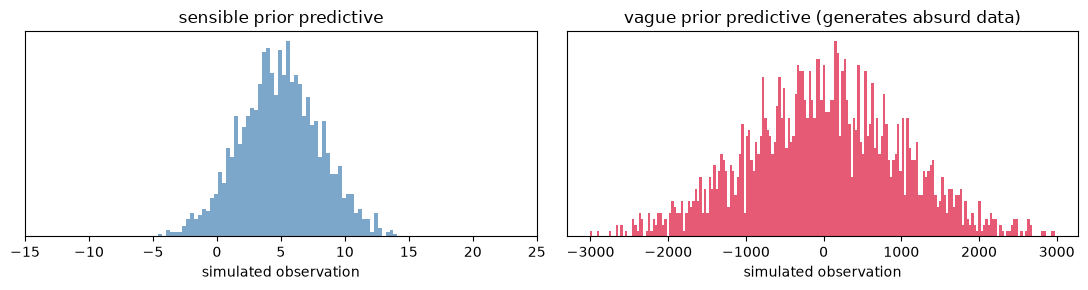

vague prior generates data from -3006 to 2980 -- physically impossible for this quantity


In [2]:
def prior_predictive(prior_mean_sd, n_param=2000, reps=1):
    m0, s0 = prior_mean_sd
    mus = rng.normal(m0, s0, n_param)            # draw the unknown mean from the prior
    return rng.normal(mus, 1.0)                   # then draw data given each

sensible = prior_predictive((5.0, 3.0))           # prior centered near the truth, moderate spread
vague = prior_predictive((0.0, 1000.0))           # absurdly diffuse prior
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(sensible, bins=60, color='steelblue', alpha=0.7); ax[0].set_title('sensible prior predictive'); ax[0].set_xlim(-15, 25)
ax[1].hist(vague, bins=200, color='crimson', alpha=0.7); ax[1].set_title('vague prior predictive (generates absurd data)')
for a in ax: a.set_yticks([]); a.set_xlabel('simulated observation')
plt.tight_layout(); plt.show()
print('vague prior generates data from %.0f to %.0f -- physically impossible for this quantity' % (vague.min(), vague.max()))

## 2. Posterior predictive: does the fitted model look like the data?

After fitting, draw replicated datasets from the posterior predictive (new data, integrating over parameter uncertainty) and compare a test statistic of the replicas to the same statistic on the observed data. If the observed value sits in the tail of the replicated distribution, the model is missing something. The classic catch: a unimodal model fit to bimodal data - the means match, but the shape statistic (here, how much mass sits near the center) betrays the misfit.


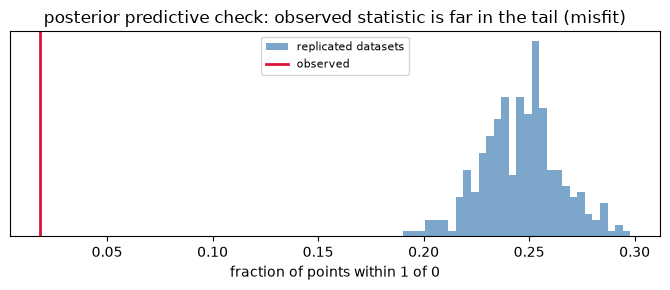

observed=0.018, posterior-predictive p-value=1.000 -> the single Gaussian misses the bimodality


In [3]:
# real data is bimodal; we (mis)fit a single Gaussian
obs = np.concatenate([rng.normal(-3, 1, 250), rng.normal(3, 1, 250)])
fit = Normal(Normal(0, 10, name='mu'), float(obs.std())).fit(list(obs))   # deliberately a single Gaussian
ppc = np.array([fit.predict(len(obs)) for _ in range(300)])      # 300 replicated datasets

# test statistic: fraction of points within 1 unit of 0 (a "hole in the middle" detector)
stat = lambda d: np.mean(np.abs(np.asarray(d)) < 1.0)
obs_stat = stat(obs); rep_stats = np.array([stat(r) for r in ppc])
pval = np.mean(rep_stats >= obs_stat)
fig, ax = plt.subplots(figsize=(6.8, 3))
ax.hist(rep_stats, bins=30, color='steelblue', alpha=0.7, label='replicated datasets')
ax.axvline(obs_stat, color='crimson', lw=2, label='observed')
ax.set_xlabel('fraction of points within 1 of 0'); ax.set_yticks([]); ax.legend(fontsize=8)
ax.set_title('posterior predictive check: observed statistic is far in the tail (misfit)')
plt.tight_layout(); plt.show()
print('observed=%.3f, posterior-predictive p-value=%.3f -> the single Gaussian misses the bimodality' % (obs_stat, pval))

## 3. Calibration: do 90% intervals contain the truth 90% of the time?

A posterior is only trustworthy if its uncertainty is calibrated. The check (a lite simulation-based calibration): repeatedly draw a true parameter, generate data, fit, and record whether the central 90% credible interval contains the truth. Over many replications that hit-rate should be $\approx 0.90$. We run it for the conjugate Normal mean.


In [4]:
hits = []
for _ in range(400):
    true_mu = rng.normal(5, 3)
    d = list(rng.normal(true_mu, 2.0, 60))
    draws = np.asarray(Normal(Normal(0, 10, name='mu'), 2.0).fit(d).posterior('mu'))   # exact posterior draws
    lo, hi = np.percentile(draws, [2.5, 97.5])                    # 95% credible interval
    hits.append(lo <= true_mu <= hi)
print('95%% credible-interval coverage over 400 replications: %.3f (target 0.95)' % np.mean(hits))

95% credible-interval coverage over 400 replications: 0.927 (target 0.95)


## Simulation-based calibration

The gold-standard check that inference is correct is simulation-based calibration (Talts et al. 2018): if you draw $\theta\sim$ prior, simulate data, and fit, the rank of the true $\theta$ among the posterior draws is uniform when the posterior is right. We run a lite SBC for the conjugate Normal mean and confirm the rank histogram is flat (a ∪ or ∩ shape would signal under- or over-dispersed posteriors).


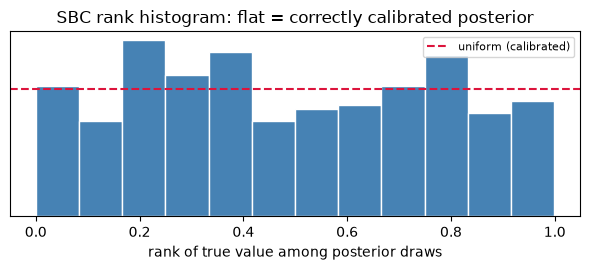

KS test of ranks vs Uniform(0,1): p=0.30 (large p = calibrated)


In [5]:
ranks = []
for _ in range(400):
    true_mu = rng.normal(0, 5)                      # draw from the prior
    d = list(rng.normal(true_mu, 2.0, 30))          # simulate data
    draws = np.asarray(Normal(Normal(0, 5, name='mu'), 2.0).fit(d).posterior('mu'))
    ranks.append(float(np.mean(draws < true_mu)))   # rank statistic in [0,1], uniform iff calibrated
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.hist(ranks, bins=12, color='steelblue', edgecolor='w')
ax.axhline(len(ranks) / 12, color='crimson', ls='--', label='uniform (calibrated)')
ax.set_xlabel('rank of true value among posterior draws'); ax.set_yticks([]); ax.legend(fontsize=8)
ax.set_title('SBC rank histogram: flat = correctly calibrated posterior')
plt.tight_layout(); plt.show()
from scipy.stats import kstest
print('KS test of ranks vs Uniform(0,1): p=%.2f (large p = calibrated)' % kstest(ranks, 'uniform').pvalue)

## References

- Gelman, A., Meng, X.-L. & Stern, H. (1996). Posterior predictive assessment of model fitness via realized discrepancies (https://www.jstor.org/stable/24306036). Statistica Sinica 6, 733-807.
- Gabry, J., Simpson, D., Vehtari, A., Betancourt, M. & Gelman, A. (2019). Visualization in Bayesian workflow (https://doi.org/10.1111/rssa.12378). JRSS-A 182(2), 389-402.
- Talts, S., Betancourt, M., Simpson, D., Vehtari, A. & Gelman, A. (2018). Validating Bayesian inference algorithms with simulation-based calibration (https://arxiv.org/abs/1804.06788). arXiv:1804.06788.
- Gelman, A. et al. (2020). Bayesian Workflow (https://arxiv.org/abs/2011.01808). arXiv:2011.01808.
- Gelman, A. et al. (2013). Bayesian Data Analysis (http://www.stat.columbia.edu/~gelman/book/), 3rd ed. CRC Press.


## Exercises and extensions

1. Simulation-based calibration. Implement full SBC (Talts et al. 2018): repeatedly draw $\theta\sim$ prior, simulate data, fit, and record the rank of the true $\theta$ among posterior draws. Plot the rank histogram - uniform means calibrated. Then break the model (wrong likelihood or a too-tight prior) and show the rank histogram deviate (∪- or ∩-shaped), diagnosing the failure.
2. Designing posterior-predictive test statistics. For a model that fits the mean but misses higher moments, build a battery of discrepancy statistics (Gelman-Meng-Stern realized discrepancies: skew, excess zeros, max, autocorrelation) and report Bayesian p-values; show which statistic catches which kind of misfit. The lesson: a PPC is only as sharp as the statistic.
3. A full Bayesian-workflow case study. Take a real dataset and walk the Gelman et al. (2020) workflow end to end: prior predictive check → fit → convergence diagnostics → posterior predictive check → model expansion → comparison (model_selection_and_cross_validation). Document each decision and what the check revealed.
4. Calibration under model misspecification. Deliberately use a too-narrow likelihood and measure credible-interval coverage degrading below nominal; then widen / use a robust likelihood and recover calibration.
